<a href="https://colab.research.google.com/github/rashzy/pcos-prediction/blob/main/pcos_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle

from sklearn.ensemble import RandomForestClassifier


# Load dataset

data = pd.read_excel(
"/PCOS_data_without_infertility.xlsx",
sheet_name="Full_new"
)

print("Original Shape:", data.shape)
data.info()

# first 5 rows
data.head()

Using Colab cache for faster access to the 'polycystic-ovary-syndrome-pcos' dataset.
Original Shape: (541, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null 

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# DATA cleaning

In [ ]:
# Clean column names (remove spaces)

data.columns = data.columns.str.strip()

#  Remove unwanted columns

cols_to_drop = ['Sl. No', 'Patient File No.', 'Unnamed: 44']
for col in cols_to_drop:
    if col in data.columns:
        data = data.drop(col, axis=1)

print("Shape after dropping columns:", data.shape)

Shape after dropping columns: (541, 42)


# data preparation

In [ ]:
#convert obj into num
# ===============================
# AMH column
if 'AMH(ng/mL)' in data.columns:
    data['AMH(ng/mL)'] = pd.to_numeric(data['AMH(ng/mL)'], errors='coerce')

# II beta-HCG column (contains 'II')
beta_cols = [col for col in data.columns if 'II' in col]
for col in beta_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [ ]:

#  Handle missing values

print("Missing values before filling:\n", data.isnull().sum())

# fill missing values only for numeric columns
data = data.fillna(data.mean(numeric_only=True))

print("Missing values after filling:\n", data.isnull().sum())


#  Remove duplicates
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

data = data.drop_duplicates()

print("Shape after removing duplicates:", data.shape)




Missing values before filling:
 PCOS (Y/N)                0
Age (yrs)                 0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     1
Pregnant(Y/N)             0
No. of aborptions         0
I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)    1
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                1
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fast food (Y/N)           1
Reg.Exercise(Y/N

In [ ]:

# Convert object → numeric

import pandas as pd
import numpy as np

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Fill missing values

data = data.fillna(data.mean(numeric_only=True))


# Separate X and y

y = data['PCOS (Y/N)']        # target
X = data.drop(['PCOS (Y/N)'], axis=1)

# ===============================
# Scaling
# ===============================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===============================
# Train Test Split
# ===============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (432, 41) (432,)
Testing set: (109, 41) (109,)


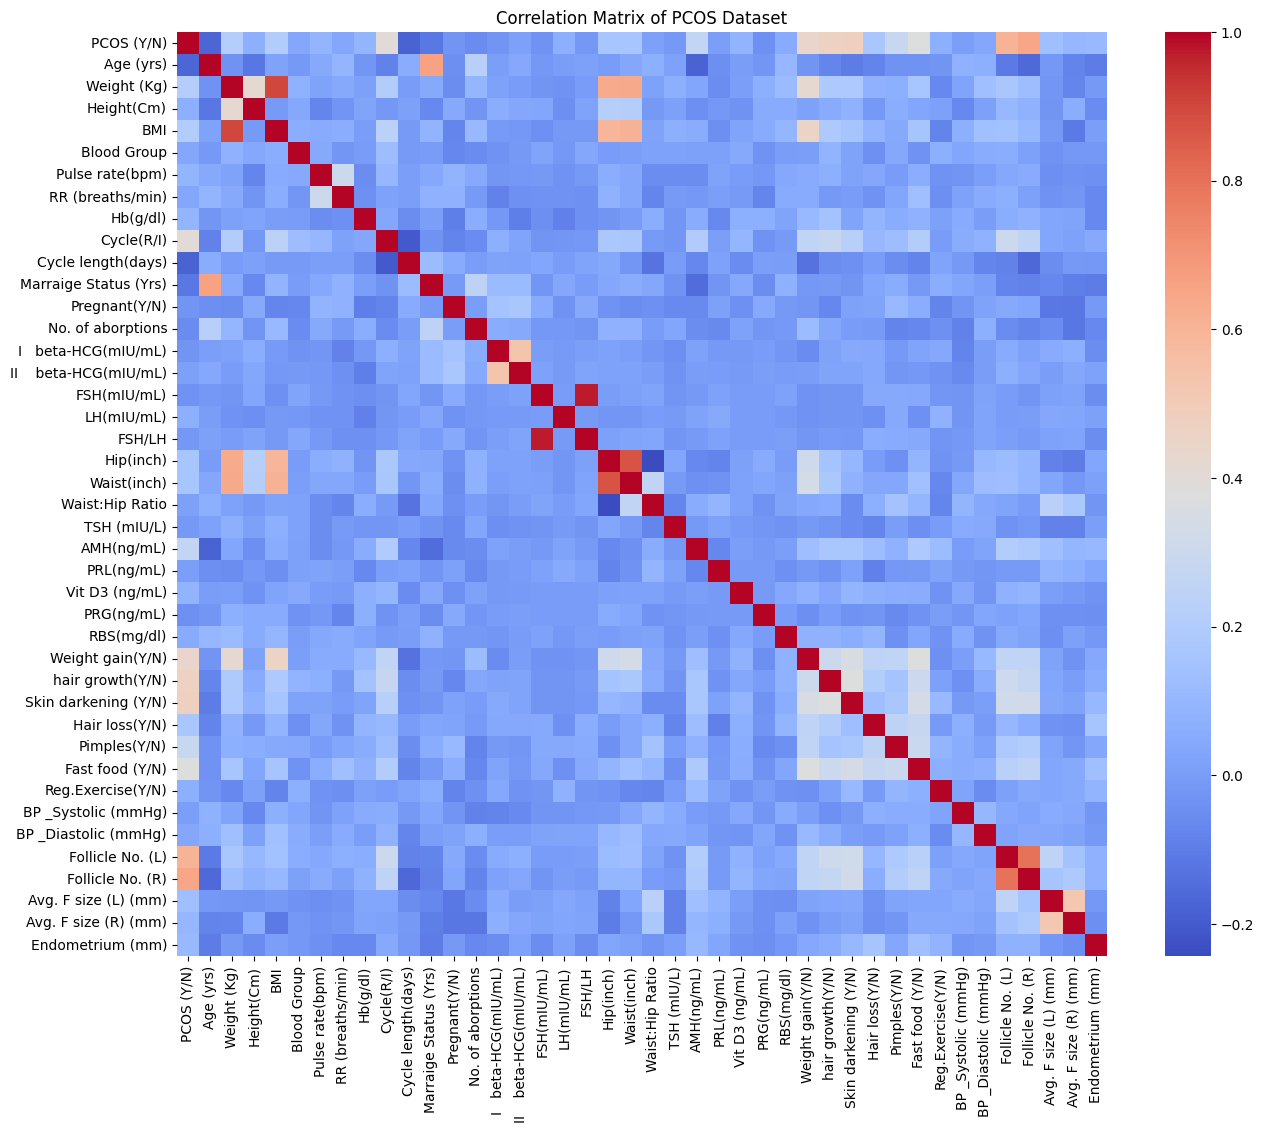

In [ ]:
# Optional: Correlation matrix
# ===============================
plt.figure(figsize=(15,12))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Correlation Matrix of PCOS Dataset")
plt.show()

# EDA

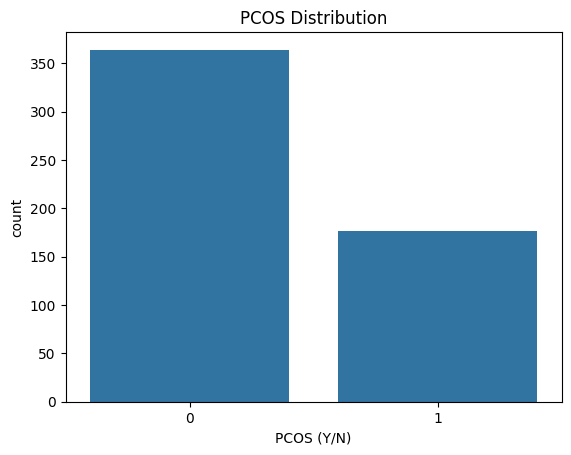

In [ ]:
#PCOS Distribution
sns.countplot(x=data['PCOS (Y/N)'])
plt.title("PCOS Distribution")
plt.show()

In [ ]:
print(data.columns)

Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
       'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
       'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
       'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')


In [ ]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI',
       'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)',
       'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
       'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')


# features selection


In [ ]:


features = [
    'Follicle No. (L)',
    'Follicle No. (R)',
    'Skin darkening (Y/N)',
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Cycle(R/I)',
    'Fast food (Y/N)',
    'Cycle length(days)',
    'AMH(ng/mL)',
    'BMI',
    'Pimples(Y/N)'
]

# Select features
X = data[features]

# Target variable
y = data['PCOS (Y/N)']

# Convert all features to numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill missing values
X = X.fillna(X.median())

print("Selected Features:")
print(X.columns)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Selected Features:
Index(['Follicle No. (L)', 'Follicle No. (R)', 'Skin darkening (Y/N)',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Cycle(R/I)', 'Fast food (Y/N)',
       'Cycle length(days)', 'AMH(ng/mL)', 'BMI', 'Pimples(Y/N)'],
      dtype='object')
Shape of X: (541, 11)
Shape of y: (541,)


/tmp/ipykernel_6111/3207074495.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = pd.to_numeric(X[col], errors='coerce')


# Model Training Part

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (432, 11)
Testing: (109, 11)


**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model training


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
accuracy = model.score(X_test_scaled, y_test)

print("Model Accuracy:", accuracy*100)

Model Accuracy: 88.07339449541286


**Sample Predictions**

In [ ]:
y_pred = model.predict(X_test_scaled)

print("Sample Predictions:", y_pred[:10])

Sample Predictions: [0 0 0 0 1 0 0 1 1 0]


In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

print(comparison)

   Actual  Predicted
0       0          0
1       0          0
2       1          0
3       0          0
4       1          1
5       0          0
6       0          0
7       0          1
8       1          1
9       0          0


# Confusion Matrix

C:
[[71  6]
 [ 7 25]]


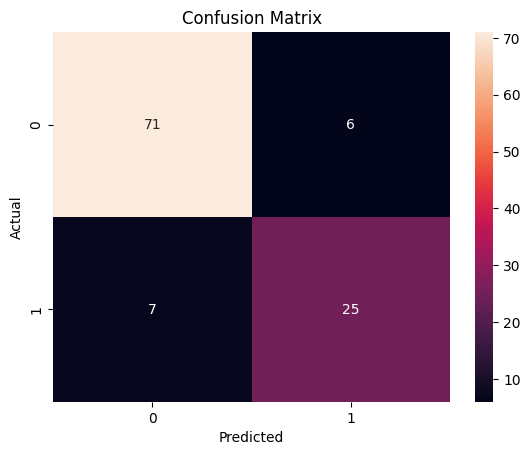

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("C:")
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92        77
           1       0.81      0.78      0.79        32

    accuracy                           0.88       109
   macro avg       0.86      0.85      0.85       109
weighted avg       0.88      0.88      0.88       109



**file save**

In [ ]:
import pickle


with open('pcos_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print(" Success! 'pcos_model.pkl' and 'scaler.pkl' have been saved in your folder.")

 Success! 'pcos_model.pkl' and 'scaler.pkl' have been saved in your folder.
